In [121]:
import pandas as pd
import numpy as np
import time
import faiss
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering, Birch, MiniBatchKMeans, KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram
import hdbscan
from sklearn.base import clone
import numpy as np
import itertools

OPIS SKUPA PODATAKA

The dataset consists of 10 numerical and 8 categorical attributes.
The 'Revenue' attribute can be used as the class label.

"Administrative", "Administrative Duration", "Informational", "Informational Duration", "Product Related" and "Product Related Duration" represent the number of different types of pages visited by the visitor in that session and total time spent in each of these page categories. The values of these features are derived from the URL information of the pages visited by the user and updated in real time when a user takes an action, e.g. moving from one page to another. The "Bounce Rate", "Exit Rate" and "Page Value" features represent the metrics measured by "Google Analytics" for each page in the e-commerce site. The value of "Bounce Rate" feature for a web page refers to the percentage of visitors who enter the site from that page and then leave ("bounce") without triggering any other requests to the analytics server during that session. The value of "Exit Rate" feature for a specific web page is calculated as for all pageviews to the page, the percentage that were the last in the session. The "Page Value" feature represents the average value for a web page that a user visited before completing an e-commerce transaction. The "Special Day" feature indicates the closeness of the site visiting time to a specific special day (e.g. Mother’s Day, Valentine's Day) in which the sessions are more likely to be finalized with transaction. The value of this attribute is determined by considering the dynamics of e-commerce such as the duration between the order date and delivery date. For example, for Valentina’s day, this value takes a nonzero value between February 2 and February 12, zero before and after this date unless it is close to another special day, and its maximum value of 1 on February 8. The dataset also includes operating system, browser, region, traffic type, visitor type as returning or new visitor, a Boolean value indicating whether the date of the visit is weekend, and month of the year.

In [122]:
exel = []

In [123]:
def plot_clusters_pca(X, labels, title):
    X = np.array(X)
    if X.ndim == 1:
        raise ValueError("Input data X must be 2D for plotting clusters.")
    if X.shape[1] < 2:
        raise ValueError("Input data X must have at least two features (columns) for 2D plotting.")
    print(title,"Silhouette:", silhouette_score(X, labels) if len(set(labels)) > 1 else "N/A")
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], cmap='tab10', s=10)
    plt.title(title)
    plt.grid(True)
    plt.show()

In [124]:
def plot_clusters(X, labels, title):
    X = np.array(X)
    if X.ndim == 1:
        raise ValueError("Input data X must be 2D for plotting clusters.")
    if X.shape[1] < 2:
        raise ValueError("Input data X must have at least two features (columns) for 2D plotting.")
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    # print(title,"Silhouette:", silhouette_score(X, labels) if len(set(labels)) > 1 else "N/A")
    plt.figure(figsize=(6, 5))
    # plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=10)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='tab10', s=10)
    plt.title(title)
    plt.grid(True)
    plt.show()

In [125]:
def metrike(title,X,labels,y):
    print("Silhouette +",title,":", silhouette_score(X, labels))
    print("Davies-Bouldin indeks: +",title,":", davies_bouldin_score(X, labels))
    ct = pd.crosstab(labels, y, normalize='index')
    print("Raspodjela ciljne po klasterima:")
    print(ct)


In [126]:
def metrike1(title,X,labels,y):
    ct = pd.crosstab(labels, y, normalize='index')
    return {
        "model": title,
        "Silhouette": round(silhouette_score(X, labels), 3),
        "Davies-Bouldin indeks": round(davies_bouldin_score(X, labels), 3),
        "Raspodjela ciljne po klasterima": ct,
    }

In [127]:
def dict_product(param_grid):
    keys = param_grid.keys()
    values = param_grid.values()
    for instance in itertools.product(*values):
        yield dict(zip(keys, instance))

In [128]:
def cluster11(model, title, X, y, params):

    best_score = -np.inf
    best_model = None
    best_params = None
    best_metrics = None

    for param_set in dict_product(params):

        m = clone(model)
        m.set_params(**param_set)

        m.fit(X)
        labels = m.labels_

        met = metrike1(title, X, labels, y)

        score = met["Silhouette"]  

        if score > best_score:
            best_score = score
            best_model = m
            best_params = param_set
            best_metrics = met

    print("Najbolji parametri:", best_params)
    print(best_metrics)
    row = {**best_params, **met}
    exel.append(row)
    print("*"*50)
    return best_model

In [129]:
def cluster22(model, title, X, y, params):

    # GRID SEARCH
    best_score = -np.inf
    best_model = None
    best_params = None
    best_metrics = None

    for param_set in dict_product(params):

        m = clone(model)
        m.set_params(**param_set)

        labels = m.fit_predict(X)
        met = metrike1(title, X, labels, y)


        score = met["Silhouette"]  

        if score > best_score:
            best_score = score
            best_model = m
            best_params = param_set
            best_metrics = met
        print("gotov!")

    print("Najbolji parametri:", best_params)
    print(best_metrics)
    row = {**best_params, **met}
    exel.append(row)
    print("*"*50)
    return best_model

In [130]:
def faisscluster1(title, X, y, params=None):

    X = np.ascontiguousarray(X.astype('float32'))
    d = X.shape[1]

    best_score = -np.inf
    best_model = None
    best_params = None
    best_metrics = None

    for param_set in dict_product(params):

        niter = param_set.get("niter")
        nredo = param_set.get("nredo",)
        seed = param_set.get("seed", 123)

        faiss_kmeans = faiss.Kmeans(d=d,k=2,niter=niter,nredo=nredo,seed=seed,verbose=False)

        faiss_kmeans.train(X)
        D, I = faiss_kmeans.index.search(X, 1)
        labels = I.flatten()

        met = metrike1(title, X, labels, y)

        score = met["Silhouette"]  

        if score > best_score:
            best_score = score
            best_model = faiss_kmeans
            best_params = param_set
            best_metrics = met
        print("gotov")
    print("Najbolji parametri:", best_params)
    print(best_metrics)
    row = {**best_params, **met}
    exel.append(row)
    print("*"*50)

    return best_model

In [131]:
df = pd.read_csv(r'podaci\online+shoppers+purchasing+intention+dataset\online_shoppers_intention preprocessed.csv', encoding='cp1252', sep=',')
print(df.columns)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')


In [132]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,2,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,2,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,2,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,2,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,2,1,0


In [133]:
y = df['Revenue']

In [134]:
X = df.copy(deep=True)

In [135]:
X = X.drop('Revenue', axis=1)

In [136]:
numeric_features = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues"
]

In [137]:
pca = PCA(n_components=2)
scaler_minmax = MinMaxScaler()
scaler_standard = StandardScaler()

In [138]:
X_log = X.copy(deep=True)

In [139]:
X_log[numeric_features] = np.log1p(X_log[numeric_features])     # Logaritamsko skaliranje
X_sca_std = scaler_standard.fit_transform(X)                    # Standard scaler
X_sca_mm = scaler_minmax.fit_transform(X)                       # MinMax scaler

X_pca = pca.fit_transform(X)

X_pca_sca_std = pca.fit_transform(X_sca_std)                    # Standard scaler + PCA
X_pca_sca_mm = pca.fit_transform(X_sca_mm)                      # MinMax scaler + PCA

In [140]:
datasets = [
    # ("Originalni podaci", X),
    # ("Log transformacija", X_log),
    # ("StandardScaler", X_sca_std),
    ("MinMaxScaler", X_sca_mm),
    # ("PCA", X_pca),
    # ("StandardScaler + PCA", X_pca_sca_std),
    # ("MinMaxScaler + PCA", X_pca_sca_mm),
]

In [141]:
# cols = X.columns
# n_cols = 2
# n_rows = len(cols)
# scaled_df_std = pd.DataFrame(X_sca_std, columns=X.columns, index=X.index)
# scaled_df_mm = pd.DataFrame(X_sca_mm, columns=X.columns, index=X.index)

In [142]:
# cols_to_plot = ["Administrative","Administrative_Duration","Informational","Informational_Duration","ProductRelated",
#         "ProductRelated_Duration","BounceRates","ExitRates","PageValues"]

# for col in cols_to_plot:
#     plt.figure(figsize=(10,4))
#     plt.suptitle(f'{col}')

#     # Prije
#     plt.subplot(1,3,1)
#     sns.histplot(scaled_df_std[col], kde=True, color="skyblue")
#     plt.title(f"Standardno skaliranje")


#     # Poslije
#     plt.subplot(1,3,3)
#     sns.histplot(X_log[col], kde=True, color="salmon")
#     plt.title(f"Logaritmsko sklairanje")

#     plt.subplot(1,3,2)
#     sns.histplot(scaled_df_mm[col], kde=True, color="green")
#     plt.title(f"MinMax skaliranje")

#     plt.tight_layout()
#     plt.show()

In [143]:
params_minibatch = {
    "n_clusters": [2],
    "batch_size": [64,128,256]
}

In [144]:
for i in range(2,3):
    mb_kmeans = MiniBatchKMeans(n_clusters=i, random_state=123)
    print("----------------"*2," Broj klastera ",i,"--------------------"*2)

    for name, X in datasets:
        cluster11(mb_kmeans,'MiniBatchKMeans', X, y,params_minibatch)

--------------------------------  Broj klastera  2 ----------------------------------------
Najbolji parametri: {'n_clusters': 2, 'batch_size': 128}
{'model': 'MiniBatchKMeans', 'Silhouette': np.float64(0.306), 'Davies-Bouldin indeks': np.float64(1.439), 'Raspodjela ciljne po klasterima': Revenue         0         1
row_0                      
0        0.851089  0.148911
1        0.826011  0.173989}
**************************************************


In [145]:
params_spectral = {
    "n_clusters": [2],
    "affinity": ["nearest_neighbors"],
    "gamma": [1, 10],
    "n_neighbors": [5,10,20],
    "assign_labels": ["kmeans", "discretize"]
}

In [146]:
for i in range(2,3):
    spectral = SpectralClustering(random_state=123)

    print("----------------"*2," Broj klastera ",i,"--------------------"*2)
    
    for name, X in datasets:
            cluster22(spectral, 'SpectralClustering', X, y,params_spectral)

--------------------------------  Broj klastera  2 ----------------------------------------


c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


gotov!


c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


gotov!
gotov!
gotov!
gotov!
gotov!


c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


gotov!


c:\Users\Korisnik\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


gotov!
gotov!
gotov!
gotov!
gotov!
Najbolji parametri: {'n_clusters': 2, 'affinity': 'nearest_neighbors', 'gamma': 1, 'n_neighbors': 10, 'assign_labels': 'kmeans'}
{'model': 'SpectralClustering', 'Silhouette': np.float64(0.306), 'Davies-Bouldin indeks': np.float64(1.438), 'Raspodjela ciljne po klasterima': Revenue         0         1
row_0                      
0        0.826239  0.173761
1        0.851014  0.148986}
**************************************************


In [147]:
params_kmeans = {
    "n_clusters": [2],
    "init": ["k-means++", "random"],
    "n_init": [10,20]
}

In [148]:
for i in range(2,3):
    kmeans = KMeans(random_state=123)
    
    print("----------------"*2," Broj klastera ",i,"--------------------"*2)
    
    for name, X in datasets:
            cluster22(kmeans,'KMeans',X,y,params_kmeans)

--------------------------------  Broj klastera  2 ----------------------------------------
gotov!
gotov!
gotov!
gotov!
Najbolji parametri: {'n_clusters': 2, 'init': 'k-means++', 'n_init': 10}
{'model': 'KMeans', 'Silhouette': np.float64(0.306), 'Davies-Bouldin indeks': np.float64(1.439), 'Raspodjela ciljne po klasterima': Revenue         0         1
row_0                      
0        0.851089  0.148911
1        0.826011  0.173989}
**************************************************


In [149]:
# params_birch = {
#     "threshold": [0.1,0.3,0.5,1.0],
#     "branching_factor": [25,50,100],
#     "n_clusters": [2]
# }

In [150]:
# for i in range(2,3):
#     birch = Birch()
    
#     print("----------------"*2," Broj klastera ",i,"--------------------"*2)
    
#     for name, X in datasets:
#             cluster11(birch,'Birch',X,y,params_birch)

In [151]:
params_faiss = {
    "n_clusters": [2],
    "niter": [20,50,100],
    "nredo": [1,5,10]
}

In [152]:
for i in range(2,3):
    print("----------------"*2," Broj klastera ",i,"--------------------"*2)

    for name, X in datasets:
            faisscluster1('Faiss',X,y,params_faiss)

--------------------------------  Broj klastera  2 ----------------------------------------
gotov
gotov
gotov
gotov
gotov
gotov
gotov
gotov
gotov
Najbolji parametri: {'n_clusters': 2, 'niter': 20, 'nredo': 1}
{'model': 'Faiss', 'Silhouette': np.float32(0.306), 'Davies-Bouldin indeks': np.float64(1.439), 'Raspodjela ciljne po klasterima': Revenue         0         1
row_0                      
0        0.851089  0.148911
1        0.826011  0.173989}
**************************************************


In [153]:
params_agg = {
    "n_clusters": [2],
    "linkage": ["ward","complete","average"]
}

In [154]:
name1 = ''

In [155]:
for i in range(2,3):
    agg = AgglomerativeClustering()

    print("---------------- Broj klastera ",i,"--------------------")

    for name, X in datasets:
            cluster22(agg,'AGG',X,y,params_agg)
            name1 = name

---------------- Broj klastera  2 --------------------
gotov!
gotov!
gotov!
Najbolji parametri: {'n_clusters': 2, 'linkage': 'average'}
{'model': 'AGG', 'Silhouette': np.float64(0.436), 'Davies-Bouldin indeks': np.float64(0.944), 'Raspodjela ciljne po klasterima': Revenue         0         1
row_0                      
0        0.845218  0.154782
1        1.000000  0.000000}
**************************************************


In [156]:
df_exel = pd.DataFrame(exel)
df_exel.to_excel(f"klasterOSI_SS/rez_{name1}.xlsx", index=False)

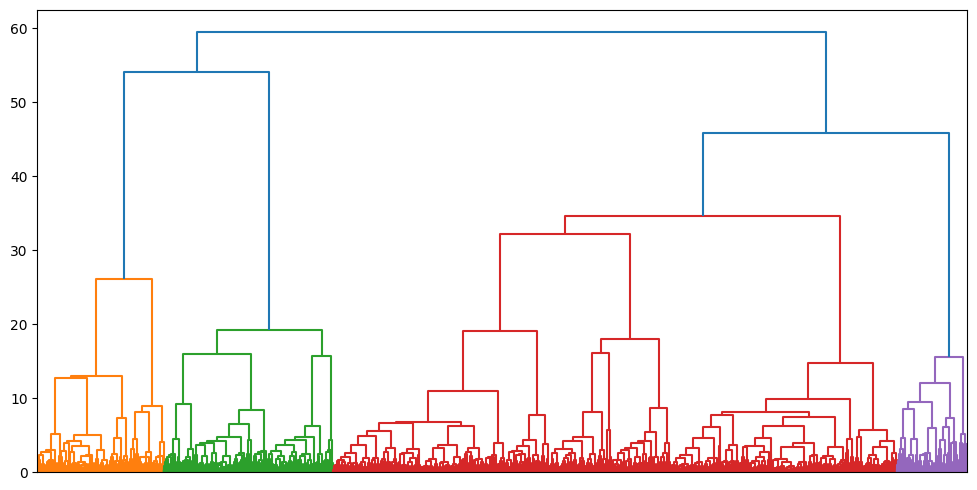

In [157]:
for name, X in datasets:
    linked = linkage(X, method='ward')

    plt.figure(figsize=(12, 6))
    dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False, no_labels=True)
    # plt.title(f'Dendogram {name}')
    plt.show()
